# ICU Patient Mortality Risk Prediction
Comparing Artificial Neural Network, Long Short-Term Memory Neural Network, and Gradient Boosting classifiers on the [PhysioNet 2012 Challenge dataset](https://physionet.org/content/challenge-2012/1.0.0/).

## Model Selection
Each model was developed independently by individual team members, leading to slight variations in preprocessing and training methods. Although this introduces some inconsistency in direct comparison, it also reflects a broader exploration of modeling approaches.

Rather than enforcing identical pipelines, we prioritized understanding how different techniques perform under realistic development conditions. Final evaluation on a shared test set ensures a consistent baseline for comparison.

In [1]:
# Imports
import glob
import os
import subprocess
import re
import pandas as pd
import numpy as np
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, precision_score, recall_score, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay, precision_recall_curve, log_loss, brier_score_loss
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LSTM
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC, Recall, Precision, BinaryAccuracy
from IPython.display import display, Markdown

In [2]:
tf.random.set_seed(42)
np.random.seed(42)

In [3]:
# Constants
GENERAL_DESCRIPTORS = {"Time", "RecordID", "Age", "Gender", "Height", "ICUType", "Weight"}
BIOMETRICS = GENERAL_DESCRIPTORS - {"Time", "ICUType"}
MODELS_DIR = "../artifacts/models"
RESULTS_DIR = "../artifacts/results"

In [4]:
def clean_patient_data(patient_file: str) -> pd.DataFrame:
    """
    Cleans a single patient's data.

    Args:
        patient_file (str): The path to the patient's data file.

    Returns:
        pd.DataFrame: The cleaned patient time series with columns:
        RecordID, Time, and one column per vital sign.
    """
    df = pd.read_csv(patient_file)

    # Clean time into minutes since.
    def to_minutes(time_str):
        h, m = map(int, time_str.split(':'))
        return h * 60 + m

    df["Time"] = df["Time"].apply(to_minutes)

    # Extract RecordID and remove it. We'll convert it into its own column.
    recordid = df.loc[df["Parameter"] == "RecordID", "Value"].values[0]
    df = df[df["Parameter"] != "RecordID"]

    # Pivot the data to have parameters as columns and timestamps as rows
    df = df.pivot_table(index="Time", columns="Parameter",
                        values="Value")

    # Sort by time for aggregation later.
    df.sort_index(inplace=True)

    # Per dataset description. -1 means it is missing value
    df = df.mask(df == -1)

    # Flatten to a tidy table for concatenation across all patients.
    df = df.reset_index()
    df["RecordID"] = int(recordid)
    return df

In [5]:
def _load_outcomes(data_set: str, data_root: str) -> pd.DataFrame:
    """
    Load survival outcomes for the selected dataset.

    Reads the outcomes file that corresponds to this loader's dataset
    identifier and returns only the columns needed for supervised learning.

    Columns:
        RecordID: Unique identifier for each patient record.
        Survival: Whether the patient survived (0) or died (1) in the ICU.

    Returns:
        pd.DataFrame: A DataFrame indexed by RecordID containing Survival.
                        Death is a binary column where 1 indicates died in ICU and 0 indicates survived.
    """
    outcomes_file_path = os.path.join(
        data_root, "outcomes", f"outcomes-{data_set}.txt")

    # We only care about RecordID and Survival
    df = pd.read_csv(outcomes_file_path, usecols=[
                     "RecordID", "Survival", "In-hospital_death"])
    df["Death"] = (df["In-hospital_death"] == 1).astype(int)
    df = df.drop(columns=["Survival", "In-hospital_death"])
    return df.set_index("RecordID")

In [6]:
def process_dataset(data_set: str, undersample: bool = False) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Loads and processes the patient data from the specified directory.
    Each set is expected to reside in a directory named
    "set-a", "set-b", or "set-c" under the data directory.

    Args:
        undersample: Whether to apply random undersampling on the majority
            class. This should generally be enabled only for training data.

    Returns:
        (pd.DataFrame, pd.DataFrame): A tuple containing the processed
        patient data and the corresponding outcomes.
        The shape of features is (record_id, vitals..., aggregated_vitals..., death),
        where each time-varying vital is expanded several aggregated features.
        Corresponding outcomes is a DataFrame indexed by RecordID containing Death.
            0 indicates patient survived, 1 indicates patient died.
    """
    if data_set not in {"a", "b", "c"}:
        raise ValueError('data_set must be one of "a", "b", or "c"')

    data_root = os.path.abspath(os.path.join("..", "..", "data"))
    dir_path = os.path.join(data_root, f"set-{data_set}")
    if not os.path.isdir(dir_path):
        raise FileNotFoundError(f"Dataset directory not found: {dir_path}")

    fp = glob.glob(os.path.join(dir_path, "*.txt"))
    patient_data = []

    for f in fp:
        patient_data.append(clean_patient_data(f))

    df_all = pd.concat(patient_data, ignore_index=True)
    outcomes = _load_outcomes(data_set, data_root)

    # Grab all vital columns. Exclude general descriptors.
    vital_columns = [c for c in df_all.columns if c not in GENERAL_DESCRIPTORS]

    # Grab biometric columns, these should not be aggregated
    biometric_columns = [c for c in df_all.columns if c in BIOMETRICS]

    # Aggregate each vital over time into one row per patient.
    grouped = df_all.groupby("RecordID")[vital_columns]
    df_mean = grouped.mean().add_suffix("_mean")
    df_median = grouped.median().add_suffix("_median")
    df_min = grouped.min().add_suffix("_min")
    df_max = grouped.max().add_suffix("_max")
    df_std = grouped.std(ddof=0).add_suffix("_std")
    df_first = grouped.first().add_suffix("_first")
    df_last = grouped.last().add_suffix("_last")
    df_missing = grouped.count().eq(0).astype(int).add_suffix("_missing")

    df_delta = (
        df_last.rename(columns=lambda c: c.replace("_last", "")) -
        df_first.rename(columns=lambda c: c.replace("_first", ""))
    ).add_suffix("_delta")

    df_range = (
        df_max.rename(columns=lambda c: c.replace("_max", "")) -
        df_min.rename(columns=lambda c: c.replace("_min", ""))
    ).add_suffix("_range")

    df_features = pd.concat(
        [
            df_mean, df_median, df_min, df_max, df_std,
            df_first, df_last, df_delta, df_missing, df_range
        ],
        axis=1
    )

    # Fill remaining NaNs
    df_features = df_features.fillna(df_features.median(numeric_only=True))

    # Fill missing biometrics: median for continuous, mode for Gender.
    # Would love to drop it but too many records are missing it.
    continuous_biometrics = [
        c for c in biometric_columns if c not in {"RecordID", "Gender"}]
    bio_medians = df_all[continuous_biometrics].median()
    df_all[continuous_biometrics] = df_all[continuous_biometrics].fillna(
        bio_medians)
    gender_mode = df_all["Gender"].mode()[0]
    df_all["Gender"] = df_all["Gender"].fillna(gender_mode)

    # One-hot encode ICUType
    icu_dummies = pd.get_dummies(df_all[["RecordID", "ICUType"]], columns=[
                                 "ICUType"], dummy_na=True)
    icu_dummies = icu_dummies.drop_duplicates(
        subset="RecordID").set_index("RecordID").astype(float)
    df_features = df_features.join(icu_dummies)

    # Add the biometrics, unaggregated.
    df_features = df_features.join(df_all[biometric_columns].drop_duplicates(
        subset="RecordID").set_index("RecordID"), how="left")

    # Sort columns to guarantee consistent feature order across datasets.
    df_features = df_features[sorted(df_features.columns)]

    if undersample:
        rus = RandomUnderSampler(sampling_strategy="majority", random_state=42)
        return rus.fit_resample(df_features, outcomes)

    return df_features, outcomes


def to_patient_timestamp_vitals(df_all: np.ndarray, outcomes: pd.DataFrame, columns) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    # Convert 2D tabular input into a 3D tensor expected by LSTM.
    # With aggregated features, each patient has one synthetic timestep.
    arr = np.asarray(df_all, dtype=np.float32)
    if arr.ndim != 2:
        raise ValueError(f"Expected a 2D array, got shape {arr.shape}")

    # Check that all columns are present in the array
    if len(columns) != arr.shape[1]:
        raise ValueError(
            f"Column count mismatch: array has {arr.shape[1]} features but got {len(columns)} columns"
        )

    # (patients, timesteps=1, vitals/features)
    X = arr.reshape(arr.shape[0], 1, arr.shape[1])

    patient_ids = outcomes.index.to_numpy()
    if len(patient_ids) != X.shape[0]:
        raise ValueError(
            f"Label count mismatch: got {len(patient_ids)} labels for {X.shape[0]} samples"
        )

    y = outcomes.loc[patient_ids, "Death"].to_numpy(dtype=np.float32)
    return X, y, patient_ids

In [7]:
def plot_metric_summary(y_true: np.ndarray, y_pred: np.ndarray, y_score: np.ndarray, title: str = 'Model'):
    """
    Prints classification report and plots roc_auc, precision, recall, and accuracy as bar chart.

    Args:
        y_true: True labels.
        y_pred: Predicted labels.
        y_score: Predicted scores or probabilities.
        title: Title for the plots and print statements.

    """
    print(f'{title} — test evaluation')
    print(classification_report(y_true, y_pred))

    roc_auc   = roc_auc_score(y_true, y_score)
    precision = precision_score(y_true, y_pred)
    recall    = recall_score(y_true, y_pred)
    accuracy  = (y_pred == y_true).mean()
    brier = brier_score_loss(y_true, y_score)

    metric_names  = ['ROC-AUC', 'Precision', 'Recall', 'Accuracy', 'Brier Score']
    metric_values = [roc_auc, precision, recall, accuracy, brier]

    plt.figure(figsize=(9, 5))
    bars = plt.bar(metric_names, metric_values, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
    plt.ylim(0, 1)
    plt.ylabel('Score')
    plt.title(f'{title} — Test Metrics')
    for bar, value in zip(bars, metric_values):
        plt.text(bar.get_x() + bar.get_width() / 2, value + 0.01, f'{value:.3f}', ha='center', va='bottom')
    plt.tight_layout()
    # plt.savefig(f"{title}_roc_auc_precision_recall_accuracy.png")
    plt.show()

def plot_evaluation_panels(y_true: np.ndarray, y_pred: np.ndarray, y_score: np.ndarray, model_name: str = 'Model') -> tuple[plt.Figure, np.ndarray]:
    """
    Plots evaluation panels including confusion matrix, ROC curve, and precision-recall curve.

    Args:
        y_true: True labels.
        y_pred: Predicted labels.
        y_score: Predicted scores or probabilities.
        model_name: Name of the model for titles.

    Returns:
        Tuple containing the figure and axes.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=axes[0], cmap='Blues')
    axes[0].set_title(f'{model_name} Confusion Matrix')
    RocCurveDisplay.from_predictions(y_true, y_score, ax=axes[1], name=model_name)
    axes[1].set_title(f'{model_name} ROC Curve')
    PrecisionRecallDisplay.from_predictions(y_true, y_score, ax=axes[2], name=model_name)
    axes[2].set_title(f'{model_name} Precision-Recall Curve')
    plt.tight_layout()
    plt.show()
    return fig, axes

def plot_threshold_tradeoff(y_true: np.ndarray, y_score: np.ndarray, chosen_threshold: float, title: str):
    """
    Plots the tradeoff between precision, recall, and accuracy for different thresholds.

    Args:
        y_true: True labels.
        y_score: Predicted scores or probabilities.
        chosen_threshold: The threshold to highlight on the plot.
        title: Title for the plot.
    """
    # precision_recall_curve returns len(thresholds) + 1 values for precision/recall.
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_score)
    # Align by dropping the last precision/recall point (which has no matching threshold).
    accuracies = [((y_score >= t).astype(int) == y_true).mean() for t in thresholds]


    plt.figure(figsize=(9, 5))
    plt.plot(thresholds, precisions[:-1], label='Precision', color='#55A868')
    plt.plot(thresholds, recalls[:-1], label='Recall', color='#C44E52')
    plt.plot(thresholds, accuracies, label='Accuracy', color='#8172B2')
    plt.axvline(x=chosen_threshold, color='gray', linestyle='--', label=f'Chosen threshold ({chosen_threshold})')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def export_predictions(record_ids: np.ndarray, y_pred: np.ndarray, y_score: np.ndarray, model_name: str) -> str:
    """
    Exports model predictions to a CSV file.
    This needs to be used with the score.c script to produce s1 and s2 scores.

    Args:
        record_ids: Array of patient RecordIDs.
        y_pred: Predicted binary labels (0 = survived, 1 = at risk).
        y_score: Predicted risk probabilities.
        model_name: Name of the model, used to name the output file.

    Returns:
        Path to the written CSV file.
    """
    filename = os.path.join(RESULTS_DIR, f"{model_name}_predictions.csv")
    pd.DataFrame({
        "RecordID": record_ids,
        "Risk_Prediction": y_pred,
        "Risk_Probability": y_score,
    }).to_csv(filename, index=False, header=False)
    print(f"Saved predictions to {filename}")
    return filename

## Data
### Findings on data
- All sets of data are highly imbalanced where there are many more patients that passed as opposed to survived.
  - To combat this, **Random Under Sampling** is performed on the training data.
- Timeseries data tabularized into 2d. To retain some of the timeseries, aggregations were made.
  - *_delta -> Delta between first and last vital taken
  - *_first -> First vital value
  - *_last  -> Last vital value
  - *_max   -> Max vital taken
  - *_mean  -> Mean of vitals taken
  - *_median -> Median of vitals taken
  - *_min   -> Min of median taken
  - *_missing -> Flag on whether this vital was not taken
  - *_range -> Range of vitals, (max - min)
  - *_std   -> Standard deviation between vitals
### Data Splits
- **set-a**: Training set, as per the official challenge.
- **set-b**: Test set, as per the official challenge.
- **set-c**: Validation set, as per the official challenge.

## Domain Specifics
In a Hospital ICU environment it is very dangerous to miss a high risk patient, in other words, _false negatives_ are risky.

In contrast, _false positives_, may result in additional monitoring which is more acceptable than missing a critical case.

With this in mind, models are evaluated with an emphasis in _recall_, at the expense of some poorer accuracy.

**Note:**
- Thresholds are selected as it improves recall while maintaining acceptable accuracy and calibration.
- Thresholds were selected after tuning using validation set (set-c).

In [8]:
# Setup the data for MLP and GradientBoostingClassifier
df_x_train, df_y_train = process_dataset(data_set="a", undersample=True)
df_x_train_all, df_y_train_all = process_dataset(data_set="a", undersample=False)
df_x_test, df_y_test = process_dataset(data_set="b", undersample=False)
df_x_val, df_y_val = process_dataset(data_set="c", undersample=False)

scaler_2d = StandardScaler()
# Fit on the full training set for better std.
x_train_all_scaled = scaler_2d.fit_transform(df_x_train_all)
x_train_scaled = scaler_2d.transform(df_x_train)
x_test_scaled = scaler_2d.transform(df_x_test)
x_val_scaled = scaler_2d.transform(df_x_val)

y_train = df_y_train.values.ravel()
y_train_all = df_y_train_all.values.ravel()
y_test = df_y_test.values.ravel()
y_val = df_y_val.values.ravel()

mlp_classes = np.unique(y_train_all)
mlp_class_weights = compute_class_weight(
    class_weight='balanced',
    classes=mlp_classes,
    y=y_train_all,
)
mlp_class_weight = {int(label): float(weight) for label, weight in zip(mlp_classes, mlp_class_weights)}

# Dimensions of the data
print(f"Training set: {x_train_scaled.shape}, {y_train.shape}")
print(f"Full training set: {x_train_all_scaled.shape}, {y_train_all.shape}")
print(f"Validation set: {x_val_scaled.shape}, {y_val.shape}")
print(f"Test set: {x_test_scaled.shape}, {y_test.shape}")
print(f"MLP class weights: {mlp_class_weight}")

Training set: (1108, 369), (1108,)
Full training set: (4000, 369), (4000,)
Validation set: (4000, 369), (4000,)
Test set: (4000, 369), (4000,)
MLP class weights: {0: 0.5803830528148578, 1: 3.6101083032490973}


## Multilayer Perceptron Artificial Neural Network
**Primary Contributor:** Jean Luis Urena

### Reason for selection
- MLP can handle large and complex non-linear data, like that of this dataset of vitals from an ICU.
- The processed dataset is highly dimensional, and MLP can handle large tables very well.
- MLP is very flexible with regularization techniques to prevent overfitting, which in turn also improves generalization.

### Parameters and Tuning
- A threshold of > 0.35 was chosen after evaluating metrics and precision recall curves.
- The MLP hyperparameters were selected using `RandomizedSearchCV` and then reviewed using validation loss, accuracy, and recall across epochs.
- Dataset is heavily imbalanced. Instead of undersampling the majority or oversampling the minority, weights were added to maintain full training distribution.

### Findings
- Training and validation performance remain close to each other, suggesting the model is fitting well. It is neither overfitting nor underfitting and generalizing well to unseen data.
- MLP achieves a strong balance between recall, calibration and accuracy compared to the other models. Although Gradient Boosting looks to be a lot better, MLP appears to perform better generalization, as suggested by the Loss/Accuracy/Recall graphs on validation and training sets.

In [9]:
# Best parameters found:  {'model__neurons': 10, 'model__l2_reg': 0.001, 'model__dropout_rate': 0.7, 'epochs': 50, 'batch_size': 64}
early_stop = EarlyStopping(patience=30, restore_best_weights=True)
mlp_model = Sequential([
    Input(shape=(x_train_all_scaled.shape[1],)),
    Dense(10, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.7),
    BatchNormalization(),
    Dense(1, activation='sigmoid')
])

adam_optimizer = Adam(learning_rate=0.001)
mlp_model.compile(
    optimizer=adam_optimizer,
    loss='binary_crossentropy',
    metrics=[
        AUC(name='auc'),
        Recall(name='recall'),
        Precision(name='precision'),
        BinaryAccuracy(name='accuracy')
    ]
)
history = mlp_model.fit(
    x_train_all_scaled, y_train_all,
    validation_data=(x_val_scaled, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    class_weight=mlp_class_weight,
    verbose=0
)

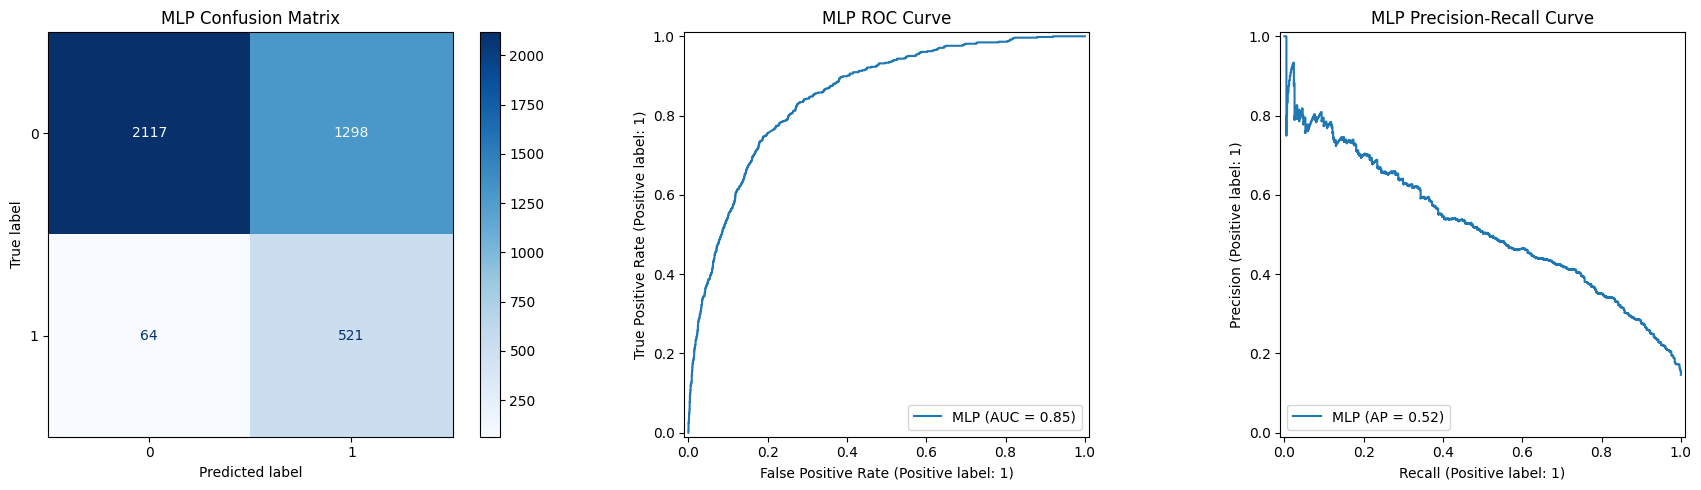

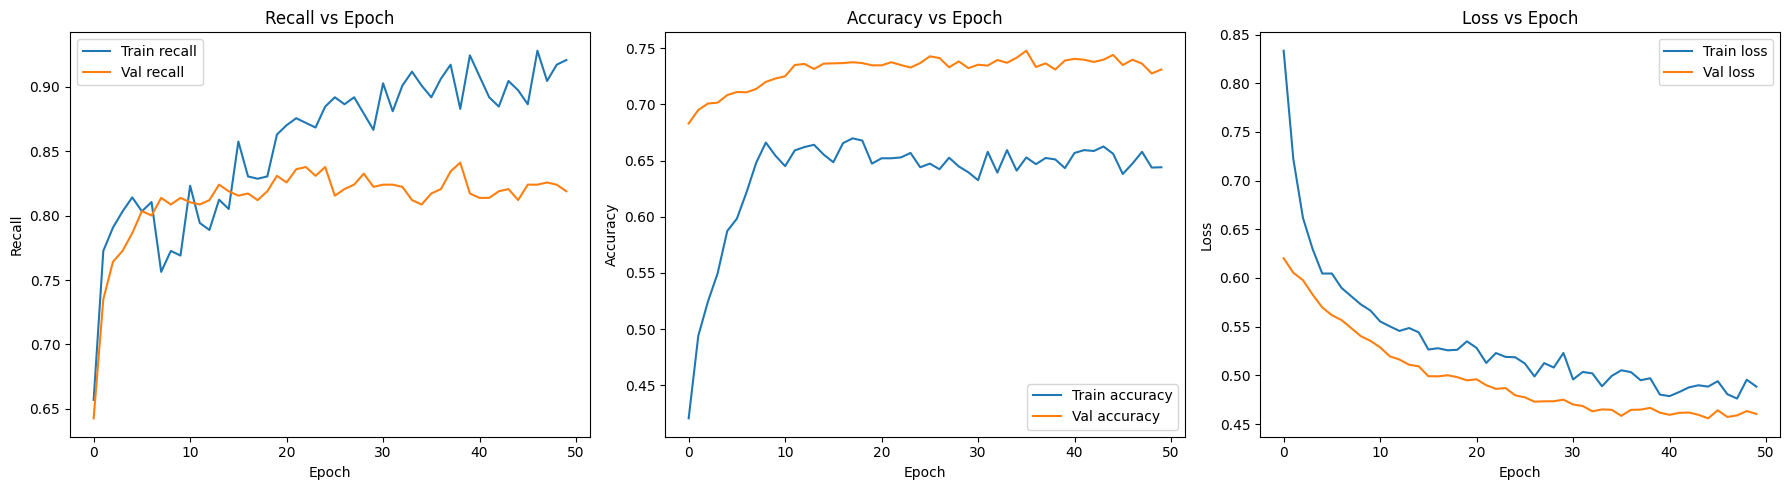

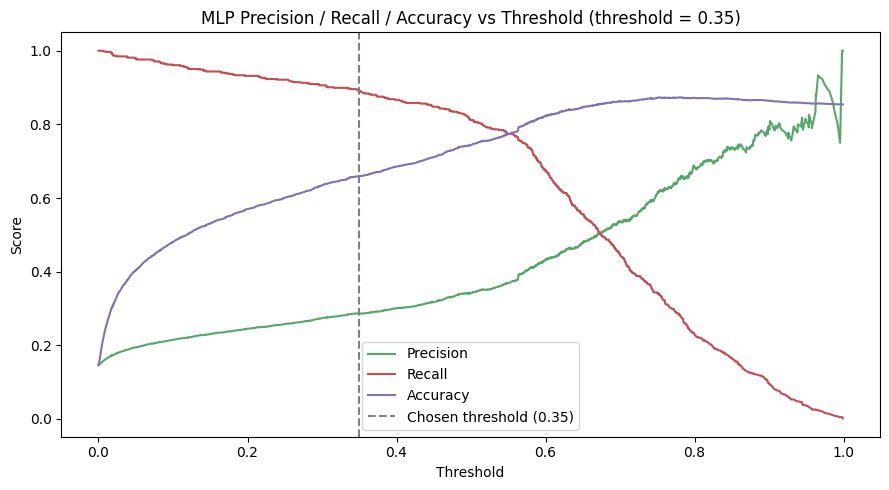

In [10]:
MLP_THRESHOLD = 0.35
mlp_val_raw_prob = mlp_model.predict(x_val_scaled, verbose=0).ravel()
mlp_calibrator = IsotonicRegression(out_of_bounds='clip')
y_val_pred = (mlp_val_raw_prob > MLP_THRESHOLD).astype(int)
mlp_calibrator.fit(mlp_val_raw_prob, y_val)

# Populate the 3-panel MLP evaluation figure.
plot_evaluation_panels(y_val, y_val_pred, mlp_val_raw_prob, model_name='MLP')

# Plot Recall, Accuracy, and Loss across epochs.
fig, metric_axes = plt.subplots(1, 3, figsize=(18, 5))

metric_axes[0].plot(history.history['recall'], label='Train recall')
metric_axes[0].plot(history.history['val_recall'], label='Val recall')
metric_axes[0].set_title('Recall vs Epoch')
metric_axes[0].set_xlabel('Epoch')
metric_axes[0].set_ylabel('Recall')
metric_axes[0].legend()

metric_axes[1].plot(history.history['accuracy'], label='Train accuracy')
metric_axes[1].plot(history.history['val_accuracy'], label='Val accuracy')
metric_axes[1].set_title('Accuracy vs Epoch')
metric_axes[1].set_xlabel('Epoch')
metric_axes[1].set_ylabel('Accuracy')
metric_axes[1].legend()

metric_axes[2].plot(history.history['loss'], label='Train loss')
metric_axes[2].plot(history.history['val_loss'], label='Val loss')
metric_axes[2].set_title('Loss vs Epoch')
metric_axes[2].set_xlabel('Epoch')
metric_axes[2].set_ylabel('Loss')
metric_axes[2].legend()

plt.tight_layout()
# plt.savefig("metrics_vs_epoch.png")
plt.show()

plot_threshold_tradeoff(
    y_val,
    mlp_val_raw_prob,
    chosen_threshold=MLP_THRESHOLD,
    title=f'MLP Precision / Recall / Accuracy vs Threshold (threshold = {MLP_THRESHOLD})'
)

## MLP Test Results
This is evaluation of test set.

MLP (threshold = 0.35, isotonic calibrated) — test evaluation
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      3432
           1       0.56      0.49      0.52       568

    accuracy                           0.87      4000
   macro avg       0.74      0.71      0.72      4000
weighted avg       0.87      0.87      0.87      4000



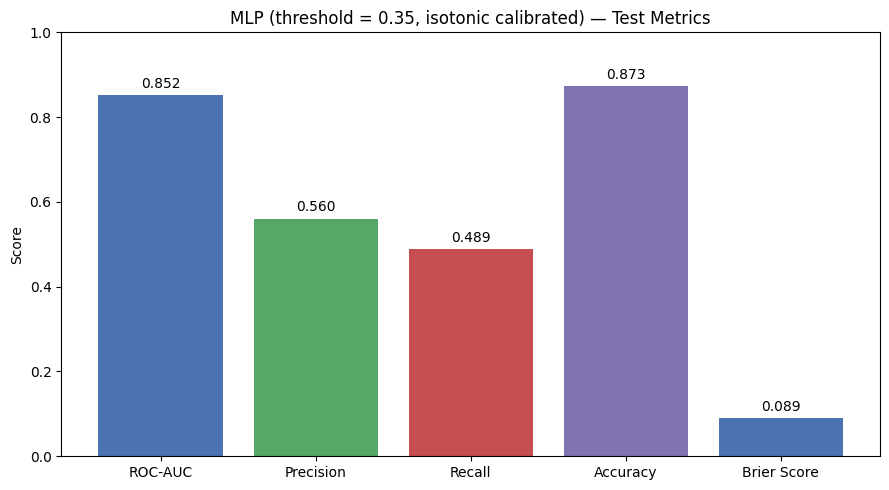

In [11]:
# Predict calibrated probabilities on test set, then apply a lower threshold to prioritize recall.
mlp_raw_prob = mlp_model.predict(x_test_scaled, verbose=0).ravel()
y_score = mlp_calibrator.predict(mlp_raw_prob)
y_pred = (y_score > MLP_THRESHOLD).astype(int)

plot_metric_summary(y_test, y_pred, y_score, f'MLP (threshold = {MLP_THRESHOLD}, isotonic calibrated)')

In [12]:
# Export MLP
export_predictions(df_y_test.index.values, y_pred, y_score, model_name='MLP')

Saved predictions to ../artifacts/results/MLP_predictions.csv


'../artifacts/results/MLP_predictions.csv'

##LSTM
Long Short-Term Memory (LSTM) is a type of Recurrent Neural Network (RNN) designed to model sequential or time-series data. It is capable of capturing temporal dependencies by maintaining an internal memory state, which allows it to retain important information over time and discard irrelevant details.

In this, LSTM is used to learn patterns in patient data and predict in-hospital mortality.

#2D to 3D Data Conversion
LSTM models require input in a 3D format:

(samples, timesteps, features)

However, our dataset is initially in a 2D tabular format:

(samples, features)

To make the data compatible with LSTM, we reshape it as follows:

(N, F) → (N, 1, F)

This means that each patient is represented as a sequence of length 1, where all engineered features are treated as a single timestep.

#LSTM Architecture
The LSTM model consists of the following layers:

Input Layer: Accepts 3D data in the form (timesteps, features) LSTM Layer: 16 units dropout = 0.2 recurrent dropout = 0.2 L2 regularization Dropout Layer: Helps prevent overfitting Dense Layer (ReLU): Learns nonlinear feature interactions Output Layer (Sigmoid): Produces probability for binary classification

The dataset is imbalanced, with fewer death cases compared to survival cases.

To address this, class weights are used:

Assign higher importance to minority class (death) Prevent model from being biased toward majority class

In [13]:
x_train_lstm_df, y_train_lstm = process_dataset("a", undersample=False)
x_val_lstm_df, y_val_lstm = process_dataset("c", undersample=False)
x_test_lstm_df, y_test_lstm = process_dataset("b", undersample=False)
print(f"Raw LSTM Training set: {x_train_lstm_df.shape}, {y_train_lstm.shape}")

# Scale before reshaping to 3D.
scaler_3d = StandardScaler()
x_train_lstm = scaler_3d.fit_transform(x_train_lstm_df)
x_val_lstm = scaler_3d.transform(x_val_lstm_df)
x_test_lstm = scaler_3d.transform(x_test_lstm_df)

print(f"LSTM Training set: {x_train_lstm.shape}, {y_train_lstm.shape}")
x_train_lstm, y_train_lstm, patient_ids_train = to_patient_timestamp_vitals(x_train_lstm, y_train_lstm, columns=x_train_lstm_df.columns)
x_val_lstm, y_val_lstm, patient_ids_val = to_patient_timestamp_vitals(x_val_lstm, y_val_lstm, columns=x_val_lstm_df.columns)
x_test_lstm, y_test_lstm, patient_ids_test = to_patient_timestamp_vitals(x_test_lstm, y_test_lstm, columns=x_test_lstm_df.columns)

Raw LSTM Training set: (4000, 369), (4000, 1)
LSTM Training set: (4000, 369), (4000, 1)


In [14]:
lstm_classes = np.unique(y_train_lstm)
lstm_class_weights = compute_class_weight(
    class_weight='balanced',
    classes=lstm_classes,
    y=y_train_lstm
)
lstm_class_weight = {int(label): float(weight) for label, weight in zip(lstm_classes, lstm_class_weights)}

lstm_early_stop = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=10,
    restore_best_weights=True
)

lstm_reduce_lr = ReduceLROnPlateau(
    monitor="val_auc",
    mode="max",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

lstm_model = Sequential([
    Input(shape=(x_train_lstm.shape[1], x_train_lstm.shape[2])),
    LSTM(
        16,
        return_sequences=False,
        dropout=0.2,
        recurrent_dropout=0.2,
        kernel_regularizer=l2(1e-3),
        recurrent_regularizer=l2(1e-3)
    ),
    Dropout(0.3),
    Dense(8, activation="relu", kernel_regularizer=l2(1e-3)),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

optimizer = Adam(learning_rate=3e-4)

lstm_model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=[
        AUC(name="auc"),
        Recall(name="recall"),
        Precision(name="precision"),
        BinaryAccuracy(name="accuracy")
    ]
)

lstm_history = lstm_model.fit(
    x_train_lstm,
    y_train_lstm,
    validation_data=(x_val_lstm, y_val_lstm),
    epochs=30,
    batch_size=64,
    callbacks=[lstm_early_stop, lstm_reduce_lr],
    verbose=0,
    class_weight=lstm_class_weight
)

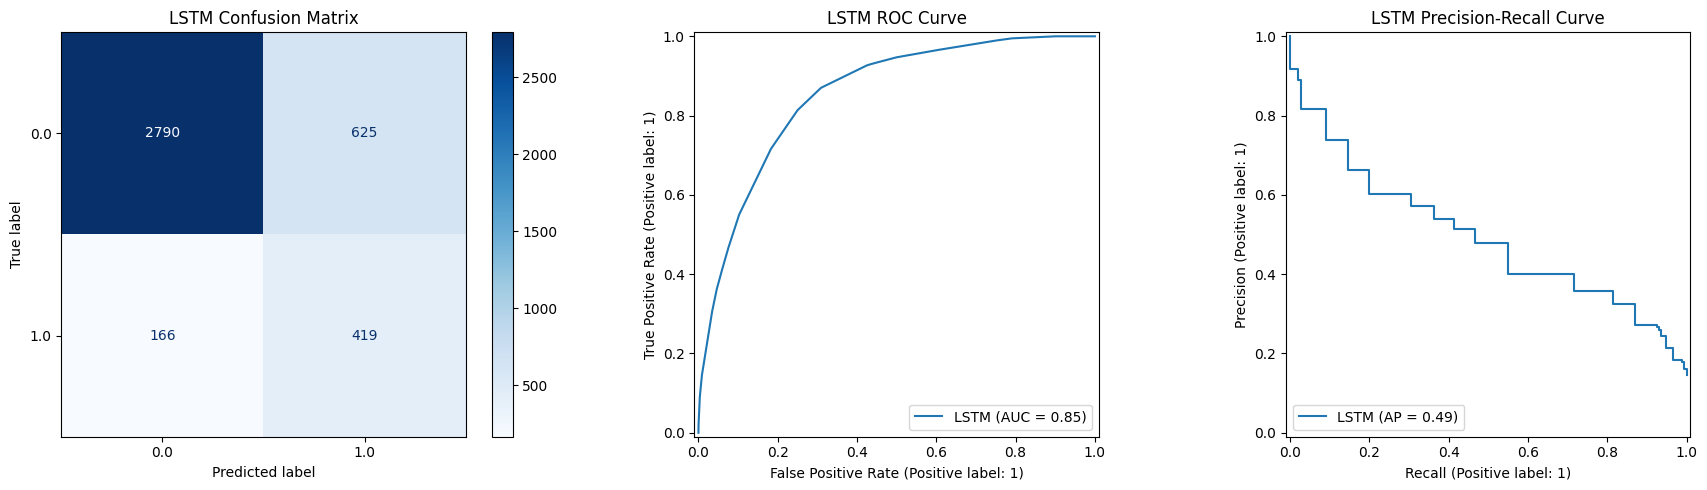

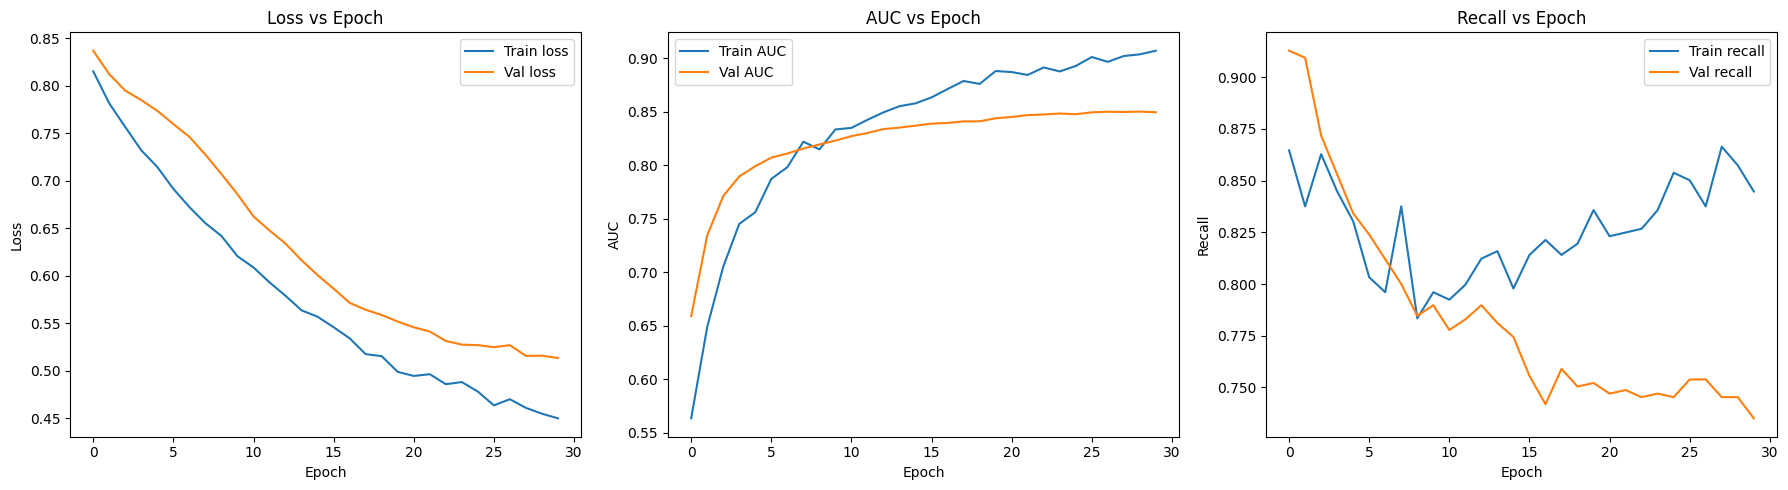

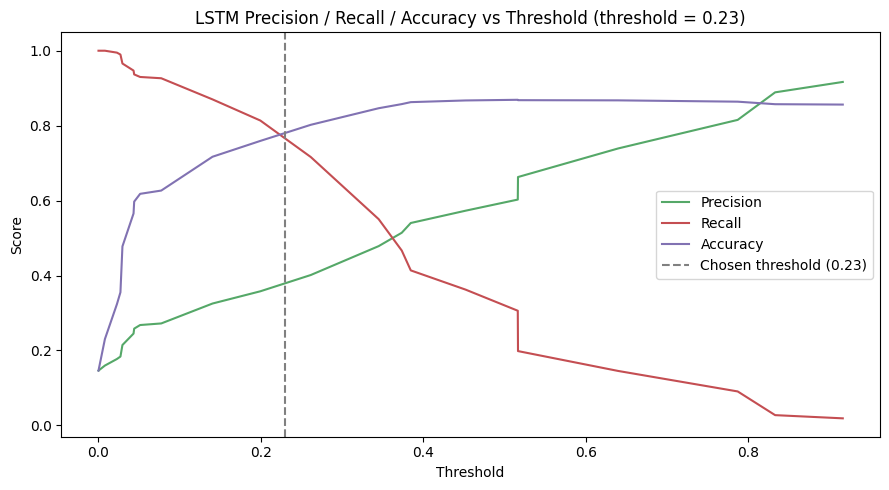

In [15]:
# Evaluate LSTM on validation set
LSTM_THRESHOLD = 0.23

lstm_val_raw_prob = lstm_model.predict(x_val_lstm, verbose=0).ravel()
lstm_calibrator = IsotonicRegression(out_of_bounds='clip')
lstm_calibrator.fit(lstm_val_raw_prob, y_val_lstm)

lstm_score = lstm_calibrator.predict(lstm_val_raw_prob)
lstm_pred = (lstm_score > LSTM_THRESHOLD).astype(int)

# Populate the 3-panel LSTM evaluation figure
plot_evaluation_panels(y_val_lstm, lstm_pred, lstm_score, model_name='LSTM')

# Plot Loss, AUC, and Recall across epochs
fig, lstm_metric_axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
lstm_metric_axes[0].plot(lstm_history.history['loss'], label='Train loss')
lstm_metric_axes[0].plot(lstm_history.history['val_loss'], label='Val loss')
lstm_metric_axes[0].set_title('Loss vs Epoch')
lstm_metric_axes[0].set_xlabel('Epoch')
lstm_metric_axes[0].set_ylabel('Loss')
lstm_metric_axes[0].legend()

# AUC
lstm_metric_axes[1].plot(lstm_history.history['auc'], label='Train AUC')
lstm_metric_axes[1].plot(lstm_history.history['val_auc'], label='Val AUC')
lstm_metric_axes[1].set_title('AUC vs Epoch')
lstm_metric_axes[1].set_xlabel('Epoch')
lstm_metric_axes[1].set_ylabel('AUC')
lstm_metric_axes[1].legend()

# Recall
lstm_metric_axes[2].plot(lstm_history.history['recall'], label='Train recall')
lstm_metric_axes[2].plot(
    lstm_history.history['val_recall'], label='Val recall')
lstm_metric_axes[2].set_title('Recall vs Epoch')
lstm_metric_axes[2].set_xlabel('Epoch')
lstm_metric_axes[2].set_ylabel('Recall')
lstm_metric_axes[2].legend()

plt.tight_layout()
plt.show()

plot_threshold_tradeoff(
    y_val_lstm,
    lstm_score,
    chosen_threshold=LSTM_THRESHOLD,
    title=f'LSTM Precision / Recall / Accuracy vs Threshold (threshold = {LSTM_THRESHOLD})'
 )

LSTM (threshold = 0.23, isotonic calibrated) — test evaluation
              precision    recall  f1-score   support

         0.0       0.95      0.83      0.88      3432
         1.0       0.41      0.73      0.53       568

    accuracy                           0.81      4000
   macro avg       0.68      0.78      0.70      4000
weighted avg       0.87      0.81      0.83      4000



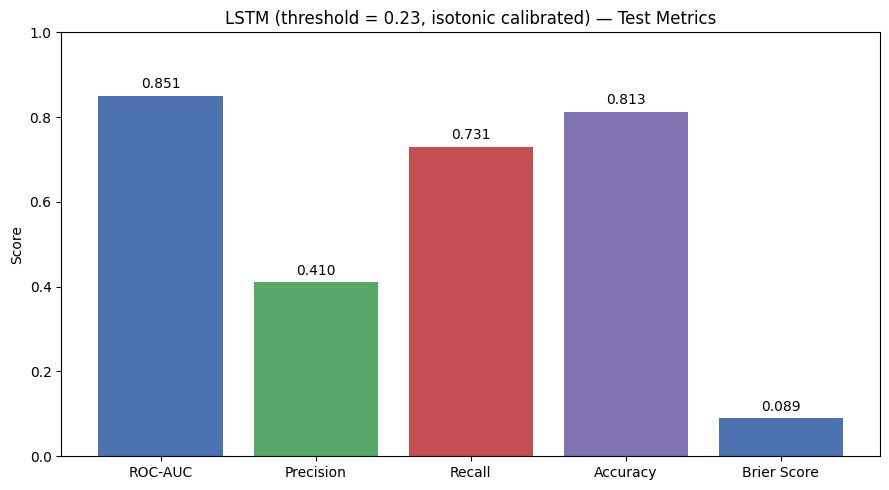

In [16]:
# Evaluate LSTM on test set using calibrated probabilities
lstm_test_raw_prob = lstm_model.predict(x_test_lstm, verbose=0).ravel()
lstm_score = lstm_calibrator.predict(lstm_test_raw_prob)
lstm_pred = (lstm_score > LSTM_THRESHOLD).astype(int)

plot_metric_summary(
    y_test_lstm,
    lstm_pred,
    lstm_score,
    title=f"LSTM (threshold = {LSTM_THRESHOLD}, isotonic calibrated)"
 )

In [17]:
export_predictions(patient_ids_test, lstm_pred, lstm_score, model_name='LSTM')

Saved predictions to ../artifacts/results/LSTM_predictions.csv


'../artifacts/results/LSTM_predictions.csv'

## Gradient Boosting Model
**Primary Contributor:** Sarvesh Kapil Pathak

- The hyperparameters used here are the best parameters found after tuning using GridSearchCV.
- Threshold was selected after tuning by iterating through a variety of thresholds.
- Training set **is not undersampled** as it impacts performance negatively. More samples better.



In [18]:
# best Params: {'learning_rate': 0.05, 'max_depth': 4, 'min_samples_leaf': 5, 'n_estimators': 200, 'subsample': 0.7}
grad_boost_params = {
    'learning_rate': 0.05,
    'max_depth': 4,
    'max_features': 'sqrt',
    'min_samples_leaf': 5,
    'n_estimators': 200,
    'random_state': 42,
    'subsample': 0.7
}

grad_boost_threshold = 0.23

gradient_boosting_model = GradientBoostingClassifier(**grad_boost_params)
# Hold out on validation set to track metrics.
gradient_boosting_model.fit(x_train_scaled, y_train)

train_prob_stages = list(gradient_boosting_model.staged_predict_proba(x_train_scaled))
val_prob_stages = list(gradient_boosting_model.staged_predict_proba(x_val_scaled))

train_loss = np.array([
    log_loss(y_train, y_proba[:, 1]) for y_proba in train_prob_stages
])
val_loss = np.array([
    log_loss(y_val, y_proba[:, 1]) for y_proba in val_prob_stages
])

train_recall = np.array([
    recall_score(y_train, (y_proba[:, 1] >= grad_boost_threshold).astype(int), zero_division=0)
    for y_proba in train_prob_stages
])
val_recall = np.array([
    recall_score(y_val, (y_proba[:, 1] >= grad_boost_threshold).astype(int), zero_division=0)
    for y_proba in val_prob_stages
])

train_accuracy = np.array([
    ((y_proba[:, 1] >= grad_boost_threshold).astype(int) == y_train).mean() for y_proba in train_prob_stages
])
val_accuracy = np.array([
    ((y_proba[:, 1] >= grad_boost_threshold).astype(int) == y_val).mean() for y_proba in val_prob_stages
])

# Refit on train+val for final test-set evaluation.
grad_boost_train_x = np.vstack([x_train_all_scaled, x_val_scaled])
grad_boost_train_y = np.hstack([y_train_all, y_val])
grad_boost_model = GradientBoostingClassifier(**grad_boost_params)
grad_boost_model.fit(grad_boost_train_x, grad_boost_train_y)

grad_boost_prob = grad_boost_model.predict_proba(x_test_scaled)[:, 1]

### Gradient Boosting Evaluation

Gradient Boosting (threshold = 0.23) — test evaluation
              precision    recall  f1-score   support

           0       0.94      0.88      0.91      3432
           1       0.48      0.67      0.56       568

    accuracy                           0.85      4000
   macro avg       0.71      0.78      0.74      4000
weighted avg       0.88      0.85      0.86      4000



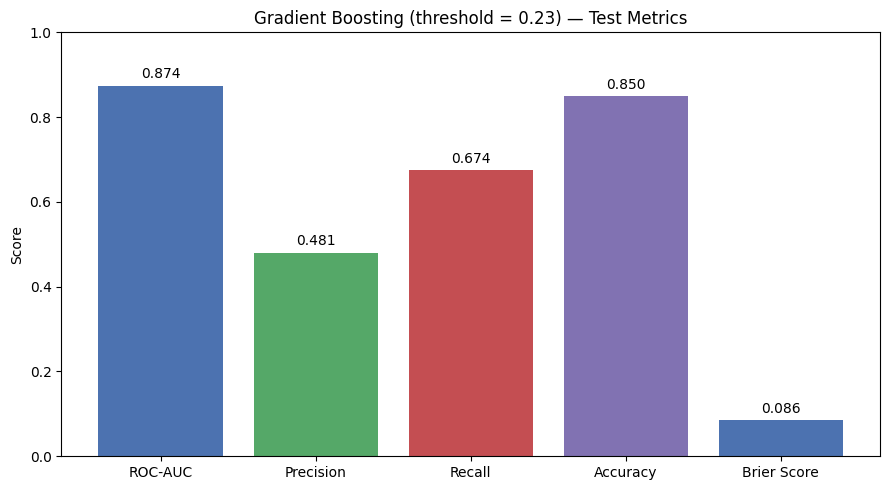

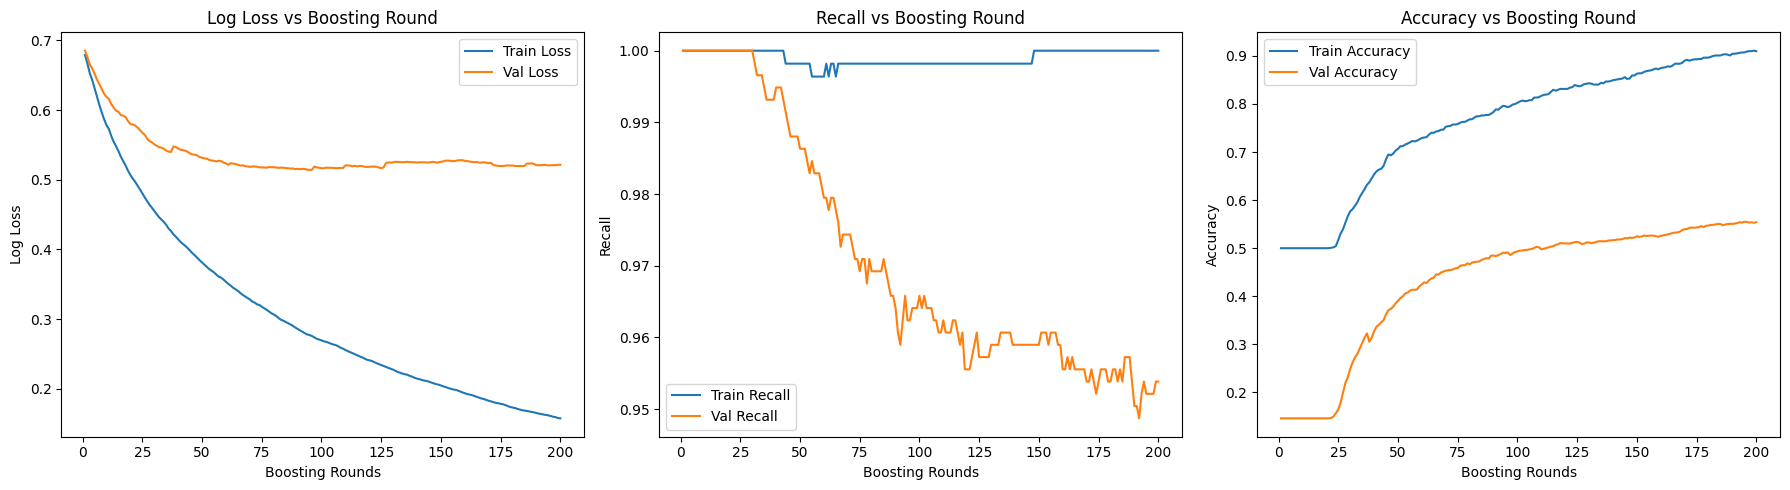

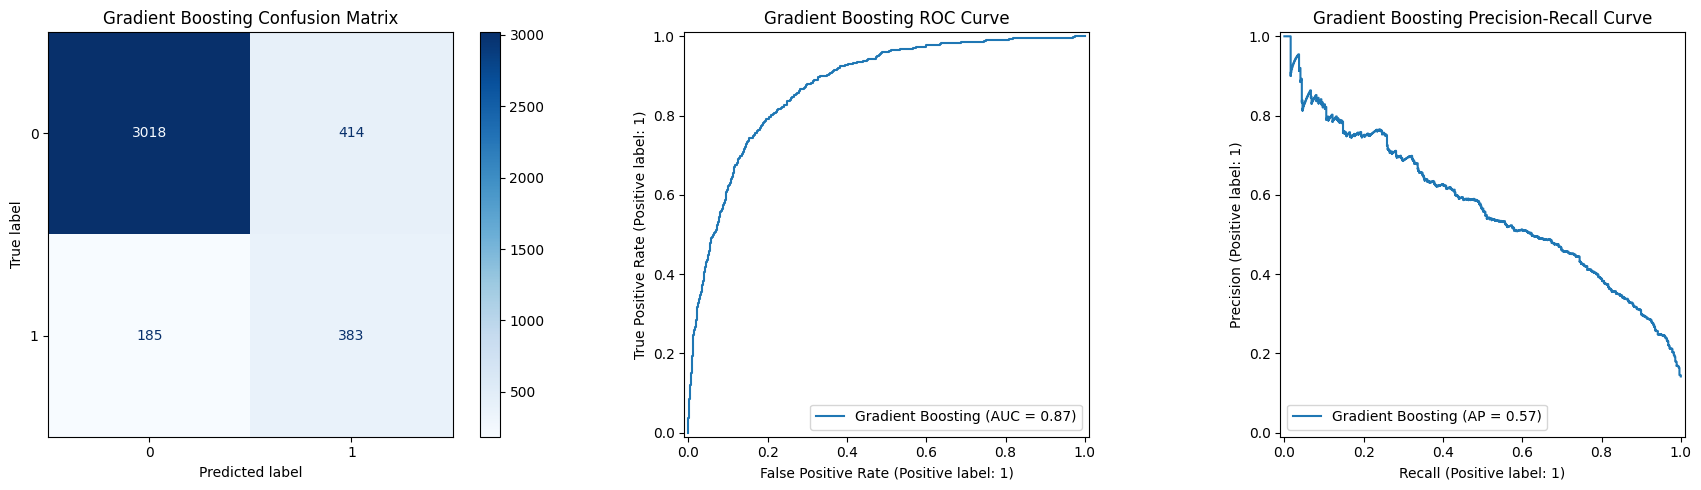

(<Figure size 1800x500 with 4 Axes>,
 array([<Axes: title={'center': 'Gradient Boosting Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>,
        <Axes: title={'center': 'Gradient Boosting ROC Curve'}, xlabel='False Positive Rate (Positive label: 1)', ylabel='True Positive Rate (Positive label: 1)'>,
        <Axes: title={'center': 'Gradient Boosting Precision-Recall Curve'}, xlabel='Recall (Positive label: 1)', ylabel='Precision (Positive label: 1)'>],
       dtype=object))

In [19]:
y_pred = (grad_boost_prob >= grad_boost_threshold).astype(int)
plot_metric_summary(y_test, y_pred, grad_boost_prob, title=f'Gradient Boosting (threshold = {grad_boost_threshold})')

epochs = np.arange(1, len(train_loss) + 1)
grad_boost_metric_fig, grad_boost_metric_axes = plt.subplots(1, 3, figsize=(18, 5))

grad_boost_metric_axes[0].plot(epochs, train_loss, label='Train Loss')
grad_boost_metric_axes[0].plot(epochs, val_loss, label='Val Loss')
grad_boost_metric_axes[0].set_title('Log Loss vs Boosting Round')
grad_boost_metric_axes[0].set_xlabel('Boosting Rounds')
grad_boost_metric_axes[0].set_ylabel('Log Loss')
grad_boost_metric_axes[0].legend()

grad_boost_metric_axes[1].plot(epochs, train_recall, label='Train Recall')
grad_boost_metric_axes[1].plot(epochs, val_recall, label='Val Recall')
grad_boost_metric_axes[1].set_title('Recall vs Boosting Round')
grad_boost_metric_axes[1].set_xlabel('Boosting Rounds')
grad_boost_metric_axes[1].set_ylabel('Recall')
grad_boost_metric_axes[1].legend()

grad_boost_metric_axes[2].plot(epochs, train_accuracy, label='Train Accuracy')
grad_boost_metric_axes[2].plot(epochs, val_accuracy, label='Val Accuracy')
grad_boost_metric_axes[2].set_title('Accuracy vs Boosting Round')
grad_boost_metric_axes[2].set_xlabel('Boosting Rounds')
grad_boost_metric_axes[2].set_ylabel('Accuracy')
grad_boost_metric_axes[2].legend()

plt.tight_layout()
plt.show()

# Populate the 3-panel Gradient Boosting evaluation figure.
plot_evaluation_panels(y_test, y_pred, grad_boost_prob, model_name='Gradient Boosting')

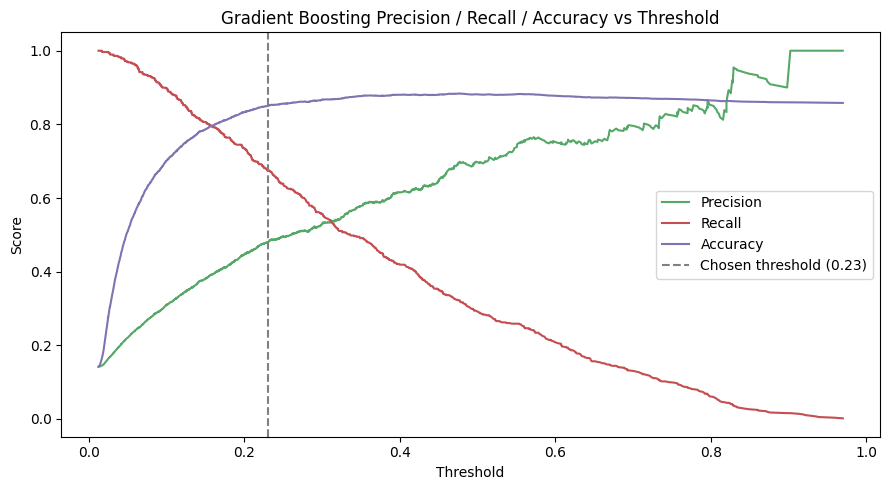

In [20]:
plot_threshold_tradeoff(
    y_test,
    grad_boost_prob,
    chosen_threshold=grad_boost_threshold,
    title='Gradient Boosting Precision / Recall / Accuracy vs Threshold'
)

In [21]:
export_predictions(df_y_test.index.values, y_pred, grad_boost_prob, model_name='GradientBoosting')

Saved predictions to ../artifacts/results/GradientBoosting_predictions.csv


'../artifacts/results/GradientBoosting_predictions.csv'

## Models Comparison


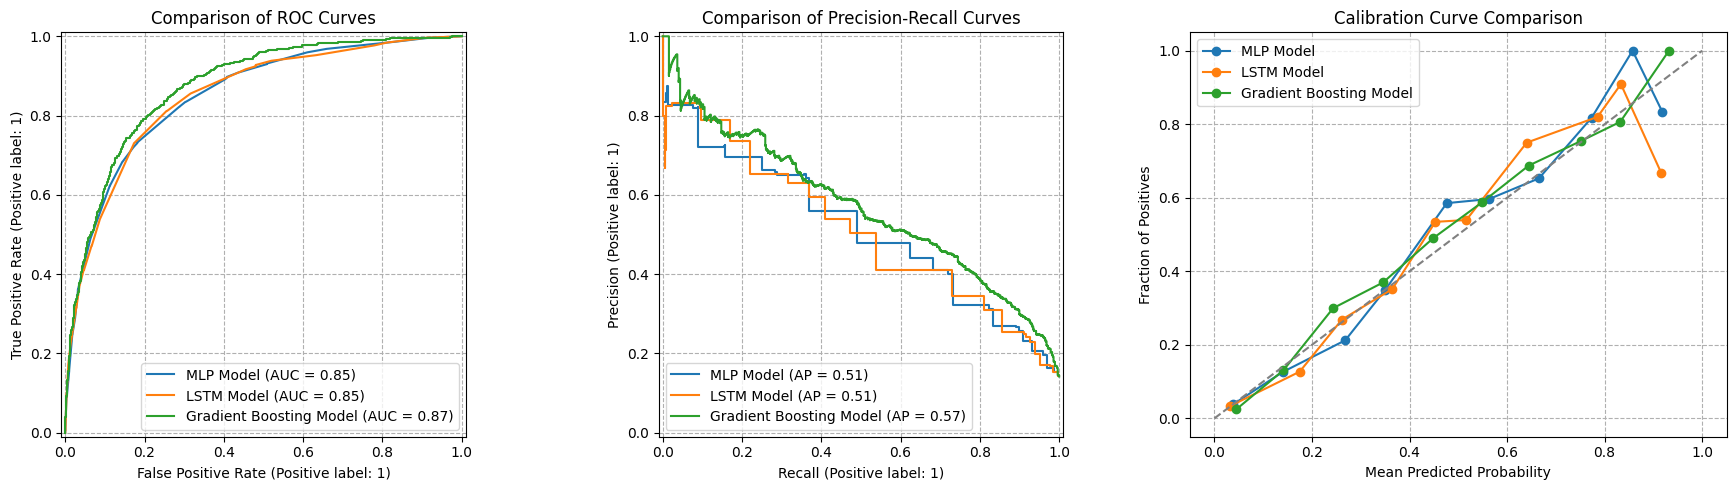

In [22]:
from sklearn.calibration import calibration_curve

# Use the same MLP probability pipeline used during MLP evaluation/export.
mlp_raw_prob = mlp_model.predict(x_test_scaled, verbose=0).ravel()
mlp_prob = mlp_calibrator.predict(mlp_raw_prob)
lstm_raw_prob = lstm_model.predict(x_test_lstm, verbose=0).ravel()
lstm_prob = lstm_calibrator.predict(lstm_raw_prob)

# Use the final refit Gradient Boosting model (train+val) for fair comparison.
grad_boost_prob = grad_boost_model.predict_proba(x_test_scaled)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC Curve: How well does the model separate classes.
RocCurveDisplay.from_predictions(y_test, mlp_prob, ax=axes[0], name='MLP Model')
RocCurveDisplay.from_predictions(y_test, lstm_prob, ax=axes[0], name='LSTM Model')
RocCurveDisplay.from_predictions(y_test, grad_boost_prob, ax=axes[0], name='Gradient Boosting Model')
axes[0].set_title('Comparison of ROC Curves')
axes[0].grid(linestyle='--')

# Precision Recall curve: How do precision and recall trade off.
PrecisionRecallDisplay.from_predictions(y_test, mlp_prob, ax=axes[1], name='MLP Model')
PrecisionRecallDisplay.from_predictions(y_test, lstm_prob, ax=axes[1], name='LSTM Model')
PrecisionRecallDisplay.from_predictions(y_test, grad_boost_prob, ax=axes[1], name='Gradient Boosting Model')
axes[1].set_title('Comparison of Precision-Recall Curves')
axes[1].grid(linestyle='--')

# Calibration curve: How well do predicted probabilities reflect true probabilities.
for prob, label in [
    (mlp_prob, 'MLP Model'),
    (lstm_prob, 'LSTM Model'),
    (grad_boost_prob, 'Gradient Boosting Model')
]:
    frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=10, strategy='uniform')
    axes[2].plot(mean_pred, frac_pos, marker='o', label=label)

axes[2].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[2].set_title('Calibration Curve Comparison')
axes[2].set_xlabel('Mean Predicted Probability')
axes[2].set_ylabel('Fraction of Positives')
axes[2].legend()
axes[2].grid(linestyle='--')

plt.tight_layout()
plt.show()

In [23]:
# Run predictions using C script for s1 and s2 scores.

pattern = re.compile(r'^(Se =|Unofficial Event 1 score:|Unofficial Event 2 score:)', re.MULTILINE)
se1_pattern = re.compile(r'Unofficial Event 1 score:\s*([\d.]+)')
se2_pattern = re.compile(r'Unofficial Event 2 score:\s*([\d.]+)')
CHALLENGE_SCORES = {}

# Run the score and store in variable to display at the end and compare with other challenges.
for model_name in ['MLP', 'LSTM', 'GradientBoosting']:
    csv_path = os.path.join(RESULTS_DIR, f"{model_name}_predictions.csv")
    # Need to support Windows 🤢
    score_bin = "./../../score" if os.name != "nt" else r"..\..\score.exe"
    outcomes_path = "../../data/outcomes/outcomes-b.txt"

    print(f"Running score for {model_name} predictions:")
    try:
        result = subprocess.run(
            [score_bin, csv_path, outcomes_path],
            capture_output=True,
            text=True
        )
        matched_lines = [line for line in result.stdout.splitlines() if pattern.match(line)]
        full_output = "\n".join(matched_lines)

        se1_match = se1_pattern.search(full_output)
        se2_match = se2_pattern.search(full_output)
        CHALLENGE_SCORES[model_name] = {
            "se1": f"{float(se1_match.group(1)):.4f}" if se1_match else None,
            "se2": f"{float(se2_match.group(1)):.4f}" if se2_match else None
        }
        print(full_output)
    except FileNotFoundError:
        print(f"  score binary not found at {score_bin}. Run 'make' first.")
    except Exception as e:
        print(f"  Error: {e}")
    print()


Running score for MLP predictions:
Se = 0.489437, PPV = 0.560484
Unofficial Event 1 score: 0.489437
Unofficial Event 2 score: 34.9821

Running score for LSTM predictions:
Se = 0.730634, PPV = 0.410485
Unofficial Event 1 score: 0.410485
Unofficial Event 2 score: 35.9592

Running score for GradientBoosting predictions:
Se = 0.674296, PPV = 0.480552
Unofficial Event 1 score: 0.480552
Unofficial Event 2 score: 54.6638



## Comparison with Physionet 2012 Challenges
- [**Winner** Patient Specific Predictions in the Intensive Care Unit
Using a Bayesian Ensemble](https://www.cinc.org/archives/2012/pdf/0249.pdf)
- [**Contestant MLP** 2012 PhysioNet Challenge: An Artificial Neural Network to Predict Mortality in
ICU Patients and Application of Solar Physics Analysis Methods](https://www.cinc.org/archives/2012/pdf/0485.pdf)

In [24]:
# Add challengers scores
CHALLENGE_SCORES["Winner (Bayesian Ensemble)"] = { "se1": "0.5310", "se2": "26.44" }
CHALLENGE_SCORES["Contestant (MLP)"] = { "se1": "0.27", "se2": "22.83" }


table = pd.DataFrame({
    model: {
        "**SE1 Score** $(\\text{min}(Se, PPV)) \\uparrow$": scores["se1"],
        "**SE2 Score** $(\\frac{HL_{\\hat{C}}}{p_D - p_1}) \\downarrow$": scores["se2"]
    }
    for model, scores in CHALLENGE_SCORES.items()
})

display(Markdown(table.to_markdown()))

|                                                             |     MLP |    LSTM |   GradientBoosting |   Winner (Bayesian Ensemble) |   Contestant (MLP) |
|:------------------------------------------------------------|--------:|--------:|-------------------:|-----------------------------:|-------------------:|
| **SE1 Score** $(\text{min}(Se, PPV)) \uparrow$              |  0.4894 |  0.4105 |             0.4806 |                        0.531 |               0.27 |
| **SE2 Score** $(\frac{HL_{\hat{C}}}{p_D - p_1}) \downarrow$ | 34.9821 | 35.9592 |            54.6638 |                       26.44  |              22.83 |

In [ ]:
# # Used to save model and standard scaler for later use in the UI.
# import joblib
# artifacts = {
#     'mlp_model': mlp_model,
#     'grad_boost_model': grad_boost_model,
#     'lstm_model': lstm_model,
#     'scaler_2d': scaler_2d,
#     'scaler_3d': scaler_3d,
# }
# for artifact_name, artifact in artifacts.items():
#     print(f"Saving {artifact_name}...")
#     joblib.dump(artifact, os.path.join(MODELS_DIR, f"{artifact_name}.joblib"))

Saving mlp_model...
Saving grad_boost_model...
Saving lstm_model...
Saving scaler_2d...
Saving scaler_3d...


## Model Comparison Findings

- **MLP** provides the best overall balance across ranking performance, recall prioritization, and probability calibration, making it the most reliable general model in this notebook.

- **Gradient Boosting** Gradient Boosting appears to be most accurate for tabular discrimination, but its evaluation metric curves suggest overfitting, so its apparent strength should be interpreted with caution.

- **LSTM** captures useful sequential patterns but is less consistent than MLP on this feature representation, so it is best viewed as a complementary baseline rather than the primary model.
